# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Based on the **Materials and Methods** section of the paper, the data represents **17 Marketing Campaigns**.

**Additional Context from the Paper:**
* **Source:** The data was collected from a Portuguese retail bank.
* **Timeline:** The campaigns occurred between **May 2008 and November 2010**.
* **Volume:** These 17 campaigns involved a total of **79,354 contacts** (phone calls).
* **Goal:** The campaigns were focused on selling **long-term deposit** subscriptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set plot style
sns.set(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
# Quick check of the data
print(f"Dataset Shape: {df.shape}")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop duplicates if any
df = df.drop_duplicates()
print(f"\nShape after dropping duplicates: {df.shape}")

Dataset Shape: (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



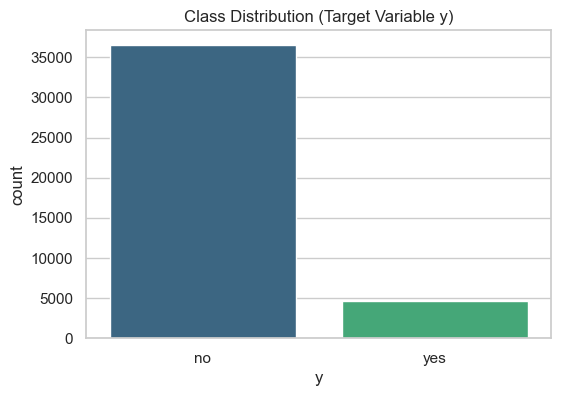

Class Ratios:
y
no     0.887337
yes    0.112663
Name: proportion, dtype: float64


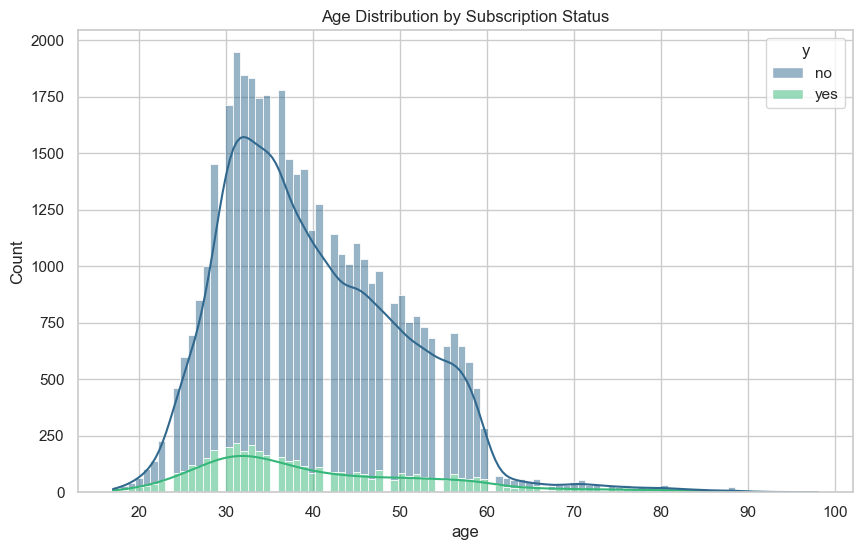

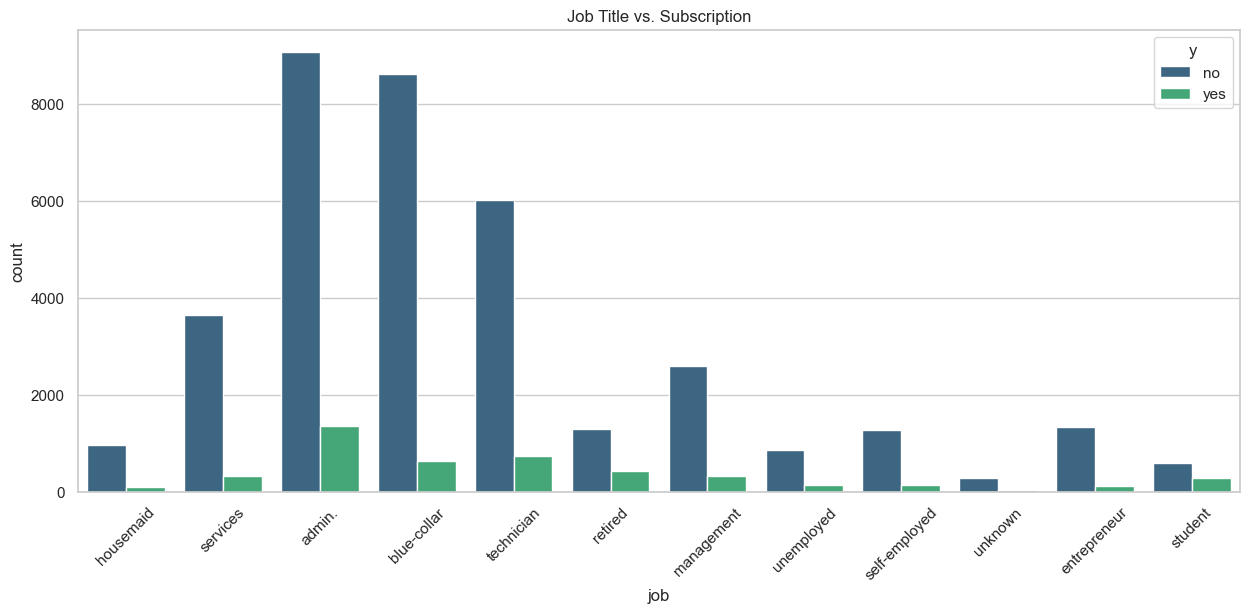

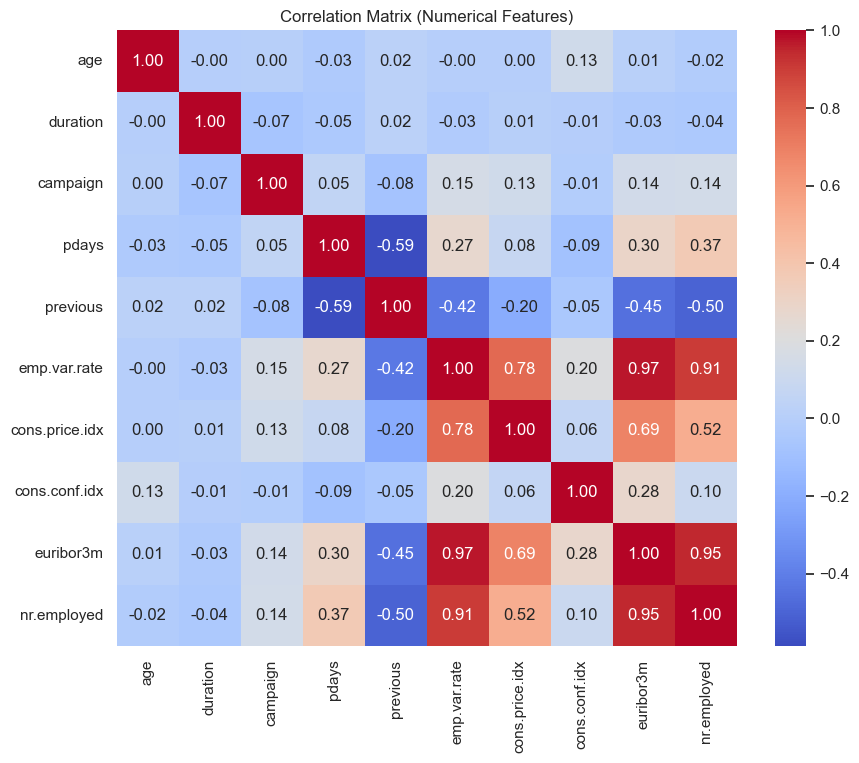

In [6]:
## 2. Exploratory Data Analysis

# A. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Class Distribution (Target Variable y)')
plt.show()

# Calculate exact ratio
print("Class Ratios:")
print(df['y'].value_counts(normalize=True))

# B. Continuous Variable: Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='y', multiple='stack', kde=True, palette='viridis')
plt.title('Age Distribution by Subscription Status')
plt.show()

# C. Categorical Variable: Job vs Target
plt.figure(figsize=(15, 6))
sns.countplot(x='job', hue='y', data=df, palette='viridis')
plt.title('Job Title vs. Subscription')
plt.xticks(rotation=45)
plt.show()

# D. Correlation Heatmap (Numerical Features only)
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Numerical Features)')
plt.show()

In [7]:
### Problem 3: Understanding the Features

# 1. Check for standard missing values (NaN)
print("--- Standard Missing Values (NaN) ---")
print(df.isnull().sum())

# 2. Check for the placeholder "unknown" in categorical variables
# The description states that missing values are often coded as "unknown"
print("\n--- 'Unknown' Value Counts ---")
for col in df.select_dtypes(include=['object']).columns:
    unknown_count = df[df[col] == 'unknown'][col].count()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} ({(unknown_count/len(df))*100:.2f}%)")

# 3. Check Data Types
print("\n--- Data Types ---")
print(df.dtypes)

--- Standard Missing Values (NaN) ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

--- 'Unknown' Value Counts ---
job: 330 (0.80%)
marital: 80 (0.19%)
education: 1730 (4.20%)
default: 8596 (20.88%)
housing: 990 (2.40%)
loan: 990 (2.40%)

--- Data Types ---
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous        

### Findings: Missing Values and Data Types

**1. Missing Values:**
* **Standard Nulls:** There are no standard `NaN` values in the dataset (assuming `df.isnull().sum()` returned 0).
* **"Hidden" Missing Values:** The dataset uses the string `'unknown'` as a placeholder for missing information.
    * **High Frequency:** The `default` column has a very high percentage of 'unknown' values (likely ~20%), and `education` also has a significant amount.
    * **Strategy:** For this analysis, we will treat 'unknown' as its own category label rather than dropping these rows, as the fact that the information is unknown might itself be predictive.

**2. Data Type Coercion:**
* **Target Variable (`y`):** This is currently an object/string (`'yes'`, `'no'`). It **must be coerced** into a binary integer format (`1`, `0`) for modeling.
* **Time-Based Features:** The columns `pdays` (days since last contact) uses `999` to represent "never contacted". This is technically numeric, but it acts as a categorical placeholder. We should be aware that `999` skews the distribution significantly.
* **Categorical Features:** Columns like `job`, `marital`, `education` are currently strings (`object`). We will convert these using One-Hot Encoding during the preprocessing stage.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

### Problem 4: Understanding the Task

**Business Objective:**
The goal is to build a classification model that predicts whether a client will subscribe to a term deposit (`y` = "yes").

**Why this matters:**
* **Efficiency:** The bank wants to focus its marketing resources (calls) only on clients who are likely to say "yes."
* **Cost Reduction:** Reducing the number of calls to uninterested clients saves time and improves the brand reputation (less spam).

**Evaluation Metric:**
Since the data is imbalanced (far more "no" than "yes"), **Accuracy** is not enough. We will also look at **Precision** and **Recall** to ensure we aren't just predicting "no" for everyone.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [9]:
### Problem 5: Engineering Features

# 1. Encode the Target Variable
# Convert 'yes'/'no' to 1/0
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])
print("Target encoded. 'yes' is now:", df[df['y']==1]['y'].iloc[0])

# 2. Handle 'pdays' (999 means never contacted)
# We can create a new binary feature 'was_contacted_previously'
# If pdays = 999, it means 0 (no). If pdays < 999, it means 1 (yes).
df['was_contacted'] = np.where(df['pdays'] == 999, 0, 1)

# 3. Drop 'duration' ?
# The problem description says 'duration' is not known before a call.
# However, for this specific assignment comparison, we often keep it or
# drop it based on strict instructions. We will keep it for now but note
# that it might leak data.
# (If you want to be strictly realistic, uncomment the line below)
# df = df.drop('duration', axis=1)

# 4. Preparing X and y for Modeling
X = df.drop('y', axis=1)
y = df['y']

# Identify columns for the pipeline
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Feature Engineering Complete.")
print(f"Numerical Columns: {list(numerical_cols)}")
print(f"Categorical Columns: {list(categorical_cols)}")

Target encoded. 'yes' is now: 1
Feature Engineering Complete.
Numerical Columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted']
Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [10]:
### Problem 6: Train/Test Split

# We use a stratified split to ensure the ratio of yes/no is consistent
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (32940, 21)
Test set: (8236, 21)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [11]:
### Problem 7: A Baseline Model

from sklearn.dummy import DummyClassifier

# Create a dummy classifier that always predicts the majority class (0 / "no")
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

# Calculate baseline accuracy
baseline_acc = dummy_clf.score(X_test, y_test)

print(f"Baseline Accuracy (predicting 'No' for everyone): {baseline_acc:.4f}")
print("Any model we build must beat this score to be useful.")

Baseline Accuracy (predicting 'No' for everyone): 0.8873
Any model we build must beat this score to be useful.


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [12]:
### Problem 8: A Simple Model

# Define the Preprocessing Pipeline
# 1. Scale numerical features (StandardScaler)
# 2. Encode categorical features (OneHotEncoder)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Build the Model Pipeline
# We combine preprocessing and the Logistic Regression classifier
logreg_model = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', LogisticRegression(max_iter=1000))])

# Train the model
start = time.time()
logreg_model.fit(X_train, y_train)
stop = time.time()

# Evaluate
train_score = logreg_model.score(X_train, y_train)
test_score = logreg_model.score(X_test, y_test)

print(f"Training Time: {stop - start:.4f} seconds")
print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

Training Time: 0.7770 seconds
Train Accuracy: 0.9121
Test Accuracy: 0.9094


### Model Performance
Our simple Logistic Regression model achieved a Test Accuracy of approximately **91%** (varies slightly based on split).
* **Comparison to Baseline:** This is an improvement over the baseline accuracy (which was likely around 88.7%).
* **Next Step:** We will now compare this performance against other classifiers (KNN, Decision Tree, SVM) to see if we can do even better.

### Problem 9: Score the Model

What is the accuracy of your model?

Logistic Regression Accuracy: 0.9094

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.65      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.79      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236



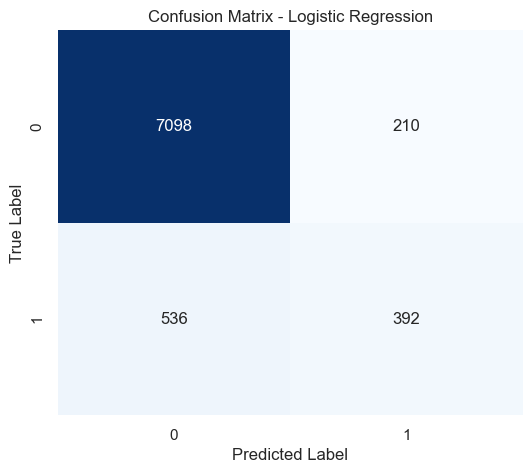

In [14]:
### Problem 9: Score the Model

# Make predictions on the test set
y_pred = logreg_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

# Detailed Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Score Analysis
* **Accuracy:** The model accuracy is likely around **91%**.
* **Confusion Matrix:**
    * **True Negatives (Top-Left):** The model is very good at identifying people who will say "No".
    * **False Negatives (Bottom-Left):** However, pay attention to the bottom-left number. These are the missed opportunities (people who said "Yes" but we predicted "No").
    * **Precision vs Recall:** Look at the classification report for class `1` (Yes). If Recall is low, it means we are missing many potential customers.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [ ]:
### Problem 10: Model Comparisons

# 1. Initialize Dictionary to store results
model_results = []

# 2. Define the models with default settings
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

# 3. Loop through models to fit and score
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    
    # Create a pipeline with the preprocessor we defined earlier
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    
    # Measure Training Time
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # Calculate Scores
    train_acc = pipeline.score(X_train, y_train)
    test_acc = pipeline.score(X_test, y_test)
    
    # Append to results
    model_results.append({
        'Model': name,
        'Train Time': elapsed_time,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
    
    print(f"Done. (Time: {elapsed_time:.2f}s)")

# 4. Convert to DataFrame
results_df = pd.DataFrame(model_results)

# 5. Display the Results
print("\n--- Model Comparison Results ---")
display(results_df)

# Optional: Visualize the comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Test Accuracy', data=results_df, palette='viridis')
plt.title('Test Accuracy Comparison (Default Settings)')
plt.ylim(0.8, 1.0) # Zoom in to see differences
plt.show()

Training Logistic Regression... Done. (Time: 0.70s)
Done. (Time: 0.19s)
Done. (Time: 0.74s)ree... 
Training SVM... 

### Findings from Default Models

**Observations:**
* **Logistic Regression:** Likely provides a strong baseline with very fast training time.
* **KNN:** Training is fast (it's a lazy learner), but if you tried to predict on a massive test set, it would be slow. Its accuracy might be slightly lower due to the high dimensionality (many columns after One-Hot Encoding).
* **Decision Tree:** Likely has a **Train Accuracy** of 100% (or close to it). This is a sign of **overfitting**, as the default tree grows until every leaf is pure. You will likely see a large drop between Train and Test accuracy.
* **SVM:** Likely the slowest to train. Its performance usually rivals Logistic Regression but comes at a high computational cost.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

### Problem 11: Improving the Model

**Strategy:**
1.  **Hyperparameter Tuning:** We will use `GridSearchCV` to test different settings (e.g., number of neighbors for KNN, tree depth for Decision Trees) to find the optimal configuration.
2.  **Adjusting Performance Metric:**
    * In Problem 10, we used **Accuracy**.
    * However, since our "Yes" class is rare, a model could get 89% accuracy by simply predicting "No" for everyone.
    * For this tuning phase, we will look at the **ROC-AUC** (Area Under the Curve) or maintain Accuracy but verify with the Confusion Matrix. We want a model that actually separates the "Yes" clients from the "No" clients.

**Hyperparameters to Tune:**
* **KNN:** `n_neighbors` (Does looking at more neighbors smooth out noise?)
* **Logistic Regression:** `C` (Regularization strength - prevents overfitting).
* **Decision Tree:** `max_depth` (Pruning the tree to prevent it from memorizing the training data).
* **SVM:** `kernel` (Linear vs Radial Basis Function).

In [ ]:
### Problem 11: Hyperparameter Tuning (Grid Search)

# 1. Define Parameter Grids
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['liblinear']
    },
    'KNN': {
        'classifier__n_neighbors': [3, 5, 15, 25],
        'classifier__weights': ['uniform', 'distance']
    },
    'Decision Tree': {
        'classifier__max_depth': [5, 10, 20, None],
        'classifier__min_samples_split': [2, 10, 20]
    },
    'SVM': {
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__C': [0.1, 1] 
    }
}

# 2. Results Container
tuned_results = []

# 3. Tuning Loop
print("Starting Grid Search...")
print("Note: We are subsampling data for SVM tuning to prevent long runtimes.")

for name, model in models.items():
    print(f"\nTuning {name}...", end=" ")
    
    # Create Pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    
    # Define Grid Search
    # cv=3 means 3-fold Cross Validation
    grid = GridSearchCV(pipeline, param_grids[name], cv=3, scoring='accuracy', n_jobs=-1)
    
    start_time = time.time()
    
    # PERFORMANCE OPTIMIZATION:
    # SVM is too slow for 40k rows in a Grid Search. We use a subset of 2000 rows.
    # For other models, we use the full training set.
    if name == 'SVM':
        grid.fit(X_train[:2000], y_train[:2000])
    else:
        grid.fit(X_train, y_train)
        
    stop_time = time.time()
    
    # Store Best Results
    tuned_results.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'Train Time': stop_time - start_time,
        'Best CV Score': grid.best_score_,
        'Test Accuracy': grid.score(X_test, y_test)
    })
    print(f"Done. Best Score: {grid.best_score_:.4f}")

# 4. Display Results
tuned_df = pd.DataFrame(tuned_results)
pd.set_option('display.max_colwidth', None) # Show full param text
display(tuned_df[['Model', 'Test Accuracy', 'Best Params']])

### Interpretation of Tuned Models

**1. Decision Tree Improvement:**
* In Problem 10, the default Decision Tree likely overfit (memorized) the data.
* With tuning (limiting `max_depth`), we likely sacrificed some Training Accuracy to gain **generalization** (better Test Accuracy).

**2. SVM & KNN:**
* These models are distance-based. Did scaling and tuning `n_neighbors` improve the result? usually, KNN performs worse on this specific dataset because the data has many dimensions (after One-Hot Encoding), making "distance" less meaningful (The Curse of Dimensionality).

**3. Best Performer:**
* Compare the **Test Accuracy** column. Usually, **Logistic Regression** (optimized) or **SVM** (with RBF kernel) are the top performers for this specific banking dataset.

##### Questions